In [1]:
"""
=============================================================================
🎯 Sioux Falls拥堵信号实验 - 最终投稿版本（μ^{t+1}=β^t 版本）
=============================================================================

核心
✅ 信念动态：司机信念不通过 P 推进，而是 μ^{t+1} = β^t

版本：Final v1.1 (pure-posterior belief update)
日期：2025-12-03
"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
from typing import Dict, Tuple, List, Optional
import time
from dataclasses import dataclass, field
import networkx as nx

print("=" * 70)
print("🚀 Sioux Falls 拥堵信号实验 - 最终投稿版本 (μ^{t+1}=β^t)")
print("=" * 70)

# =============================================================================
# 配置类
# =============================================================================

@dataclass
class Config:
    """配置 - 最终版本"""
    
    # ⭐ 网络：经典1→20对角线OD
    major_od_pairs: List[Tuple[int, int, float]] = field(default_factory=lambda: [
        (1, 20, 35000)  # 合理的主要OD流量
    ])
    k_paths_per_od: int = 3
    bpr_alpha: float = 0.15
    bpr_beta: float = 4.0
    
    # ⭐ 子网设计：三条写死的路径（不用k-shortest）
    # 路径1（高速型-北线）: 1→2→6→8→16→18→20（全主干道）
    # 路径2（稳定型-南线）: 1→3→4→5→9→10→17→19→20（全次要道）
    # 路径3（混合型-中线）: 1→3→12→13→24→21→20（部分主干）
    fixed_paths: Dict[Tuple[int, int], List[List[int]]] = field(default_factory=lambda: {
        (1, 20): [
            [1, 2, 6, 8, 16, 18, 20],        # 路径1: 高速型-北线（全主干）
            [1, 3, 4, 5, 9, 10, 17, 19, 20], # 路径2: 稳定型-南线（全次要）
            [1, 3, 12, 13, 24, 21, 20],      # 路径3: 混合型-中线
        ]
    })
    
    # ⭐ 核心：定义主干道（路径0全主干 + 路径2部分主干）
    major_roads: List[Tuple[int, int]] = field(default_factory=lambda: [
        # 路径0（高速型-北线）- 全是主干道
        (1, 2), (2, 6), (6, 8), (8, 16), (16, 18), (18, 20),
        
        # 路径2（混合型-中线）- 部分主干道
        # 注意：去掉 (1,3)，否则路径2和路径1都会被标主干
        (12, 13), (24, 21), (21, 20),
    ])
    
    # ⭐ 拥堵状态对不同类型道路的影响（增大对比度）
    congestion_multipliers: Dict[str, Dict[int, float]] = field(default_factory=lambda: {
        'major': {  # 主干道：Clear快，Heavy崩溃
            0: 0.8,   # Clear
            1: 2.5,   # Light
            2: 6.0,   # Heavy
        },
        'minor': {  # 次要道：Clear慢，Heavy稳定
            0: 1.5,   # Clear
            1: 1.8,   # Light
            2: 2.0,   # Heavy
        }
    })
    
    # SUE
    sensitivity: float = 0.6
    sue_max_iters: int = 15  # 完整SUE，不作弊
    
    # 噪声
    latency_noise_std: float = 1.0
    filter_noise_std: float = 1.5
    
    # 状态空间
    congestion_levels: List[str] = field(default_factory=lambda: ["Clear", "Light", "Heavy"])
    n_states: int = 3
    
    # 转移概率（真实拥堵状态）
    state_persistence: float = 0.5
    
    # 滤波器
    n_particles: int = 10
    resample_threshold: float = 0.5
    
    # Episode
    commit_len: int = 10
    n_commits_per_episode: int = 15
    
    # Two-Stage
    use_adaptive_switch: bool = True
    variance_threshold: float = 0.001
    min_warmup_commits: int = 2
    max_warmup_commits: int = 8
    
    # PPO
    learning_rate: float = 1e-4
    gamma: float = 0.95
    ppo_epochs: int = 4
    ppo_clip: float = 0.2
    entropy_coef: float = 0.03
    hidden_dim: int = 128
    
    # 训练
    max_timesteps: int = 5000
    update_timestep: int = 100
    log_freq: int = 500
    n_eval_episodes: int = 20
    random_seed: int = 42
    
    # Reward
    use_differential_reward: bool = True
    reward_clip_min: float = -10.0
    reward_clip_max: float = 10.0
    baseline_calibration_steps: int = 30
    
    # 信念 & 机制
    initial_belief: Optional[np.ndarray] = None
    mechanisms: Optional[List[Tuple[str, np.ndarray]]] = None
    
    def __post_init__(self):
        if self.initial_belief is None:
            # 初始信念：偏向 Clear / Light
            self.initial_belief = np.array([0.6, 0.3, 0.1])
        
        if self.mechanisms is None:
            self.mechanisms = self._create_congestion_mechanisms()
    
    def _create_congestion_mechanisms(self) -> List[Tuple[str, np.ndarray]]:
        """
        信号机制族：
        1. Perfect（上界）
        2. High-Accuracy（对称噪声0.85）
        3. Heavy-Warning（偏悲观，避免灾难）
        4. Optimistic（偏乐观，冒险）
        5. Binary-Alert（粗粒度，只分Safe/Danger）
        6. Random（基线）
        """
        mechanisms = []
        n = self.n_states
        
        # 1. Perfect（完美信息，上界）
        eta = np.eye(n)
        mechanisms.append(("Perfect", eta))
        
        # 2. High-Accuracy（对称噪声，准确率85%）
        eta = self._create_noisy_mechanism(0.85)
        mechanisms.append(("High-Accuracy", eta))
        
        # 3. Heavy-Warning（偏悲观机制）
        eta = np.array([
            [0.75, 0.10, 0.15],
            [0.10, 0.20, 0.70],
            [0.05, 0.05, 0.90],
        ])
        mechanisms.append(("Heavy-Warning", eta))
        
        # 4. Optimistic（偏乐观机制）
        eta = np.array([
            [0.85, 0.10, 0.05],
            [0.50, 0.30, 0.20],
            [0.30, 0.30, 0.40],
        ])
        mechanisms.append(("Optimistic", eta))
        
        # 5. Binary-Alert（粗粒度信号）
        eta = np.array([
            [0.90, 0.10, 0.00],
            [0.40, 0.50, 0.10],
            [0.05, 0.15, 0.80],
        ])
        mechanisms.append(("Binary-Alert", eta))
        
        # 6. Random（基线）
        eta = np.ones((n, n)) / n
        mechanisms.append(("Random", eta))
        
        return mechanisms
    
    def _create_noisy_mechanism(self, accuracy: float) -> np.ndarray:
        """对称噪声机制"""
        n = self.n_states
        eta = np.zeros((n, n))
        for true_state in range(n):
            for signal in range(n):
                if signal == true_state:
                    eta[true_state, signal] = accuracy
                else:
                    eta[true_state, signal] = (1 - accuracy) / (n - 1)
        return eta
    
    @property
    def n_actions(self) -> int:
        return len(self.mechanisms)
    
    def print_summary(self):
        print("\n" + "=" * 70)
        print("📋 配置总结")
        print("=" * 70)
        print(f"\n【子网设计】")
        print(f"  OD: 1 → 20 (对角线), 需求: {self.major_od_pairs[0][2]:,}")
        print(f"  路径1: 高速型-北线（全主干道）")
        print(f"  路径2: 稳定型-南线（全次要道）")
        print(f"  路径3: 混合型-中线（部分主干）")
        
        print(f"\n【信念动态】")
        print("  司机更新：μ^{t+1} = β^t（只用后验，不用 P 推进）")
        print("  真实状态：s_t 按 Markov P(s'|s) 转移")
        
        print(f"\n【拥堵机制】")
        print(f"  主干道 multipliers: {self.congestion_multipliers['major']}")
        print(f"  次要道 multipliers: {self.congestion_multipliers['minor']}")
        
        print(f"\n【信号机制】 共 {self.n_actions} 个")
        for name, _ in self.mechanisms:
            print(f"  - {name}")
        
        print(f"\n【SUE】 Logit ν={self.sensitivity}, 迭代 {self.sue_max_iters} 次")
        print("=" * 70 + "\n")


# =============================================================================
# 网络类
# =============================================================================

class Network:
    def __init__(self, config: Config):
        self.config = config
        self.G = self._create_sioux_falls_graph()
        self.paths = {}
        self.path_list = []
        self.od_to_path_idx = {}
        self._use_fixed_paths()
        self.n_paths = len(self.path_list)
        self.edge_path_matrix = self._build_edge_path_matrix()
        self.major_roads_set = set(self.config.major_roads)
        print(f"✅ 网络: {self.n_paths}条路径（写死，确保设计正确）")
        self._analyze_paths()
    
    def _create_sioux_falls_graph(self) -> nx.DiGraph:
        G = nx.DiGraph()
        edges = [
            (1, 2, 25900, 6), (1, 3, 23400, 4),
            (2, 1, 25900, 6), (2, 6, 4958, 5),
            (3, 1, 23400, 4), (3, 4, 17110, 4), (3, 12, 23403, 4),
            (4, 3, 17110, 4), (4, 5, 17782, 2), (4, 11, 4908, 6),
            (5, 4, 17782, 2), (5, 6, 4947, 4), (5, 9, 10000, 5),
            (6, 2, 4958, 5), (6, 5, 4947, 4), (6, 8, 4898, 2),
            (7, 8, 7840, 3), (7, 18, 23403, 2),
            (8, 6, 4898, 2), (8, 7, 7840, 3), (8, 9, 5050, 10), (8, 16, 5045, 5),
            (9, 5, 10000, 5), (9, 8, 5050, 10), (9, 10, 13915, 3),
            (10, 9, 13915, 3), (10, 11, 10000, 6), (10, 15, 9599, 7),
            (10, 16, 4824, 4), (10, 17, 5000, 8),
            (11, 4, 4908, 6), (11, 10, 10000, 6), (11, 12, 4823, 3),
            (11, 14, 4909, 4),
            (12, 3, 23403, 4), (12, 11, 4823, 3), (12, 13, 25900, 3),
            (13, 12, 25900, 3), (13, 24, 4909, 4),
            (14, 11, 4909, 4), (14, 15, 5091, 5), (14, 23, 4910, 4),
            (15, 10, 9599, 7), (15, 14, 5091, 5), (15, 19, 14564, 3),
            (15, 22, 9600, 3),
            (16, 8, 5045, 5), (16, 10, 4824, 4), (16, 17, 5229, 2),
            (16, 18, 14564, 3),
            (17, 10, 5000, 8), (17, 16, 5229, 2), (17, 19, 4824, 2),
            (18, 7, 23403, 2), (18, 16, 14564, 3), (18, 20, 23403, 4),
            (19, 15, 14564, 3), (19, 17, 4824, 2), (19, 20, 5002, 4),
            (20, 18, 23403, 4), (20, 19, 5002, 4), (20, 21, 5059, 5),
            (20, 22, 5075, 5),
            (21, 20, 5059, 5), (21, 22, 5229, 2), (21, 24, 4823, 3),
            (22, 15, 9600, 3), (22, 20, 5075, 5), (22, 21, 5229, 2),
            (22, 23, 5002, 4),
            (23, 14, 4910, 4), (23, 22, 5002, 4), (23, 24, 5075, 2),
            (24, 13, 4909, 4), (24, 21, 4823, 3), (24, 23, 5075, 2),
        ]
        for u, v, cap, fft in edges:
            G.add_edge(u, v, capacity=cap, fft=fft,
                       alpha=self.config.bpr_alpha, beta=self.config.bpr_beta)
        return G
    
    def _use_fixed_paths(self):
        for o, d, demand in self.config.major_od_pairs:
            if (o, d) in self.config.fixed_paths:
                paths = self.config.fixed_paths[(o, d)]
                print(f"\n🔧 使用写死的路径 {o}→{d}:")
                for i, p in enumerate(paths):
                    print(f"  路径{i}: {' → '.join(map(str, p))}")
            else:
                paths = list(nx.shortest_simple_paths(self.G, o, d, weight='fft'))[:self.config.k_paths_per_od]
            self.paths[(o, d)] = paths
            start_idx = len(self.path_list)
            self.od_to_path_idx[(o, d)] = list(range(start_idx, start_idx + len(paths)))
            self.path_list.extend(paths)
    
    def _build_edge_path_matrix(self) -> Dict[Tuple[int, int], np.ndarray]:
        edge_matrix = {}
        for p_idx, path in enumerate(self.path_list):
            for i in range(len(path) - 1):
                e = (path[i], path[i+1])
                if e not in edge_matrix:
                    edge_matrix[e] = np.zeros(self.n_paths)
                edge_matrix[e][p_idx] = 1.0
        return edge_matrix
    
    def _analyze_paths(self):
        print("\n📊 路径分析：")
        for idx, path in enumerate(self.path_list):
            total_edges = len(path) - 1
            major_edges = 0
            for i in range(len(path)-1):
                e = (path[i], path[i+1])
                if e in self.major_roads_set:
                    major_edges += 1
            major_pct = (major_edges / total_edges * 100) if total_edges > 0 else 0
            if major_pct >= 80:
                ptype = "高速型-北线（全主干）"
            elif major_pct <= 20:
                ptype = "稳定型-南线（全次要）"
            else:
                ptype = "混合型-中线"
            print(f"  路径{idx} [{ptype}]: {major_edges}/{total_edges}条主干道 ({major_pct:.0f}%)")
    
    def _get_edge_flow_fast(self, u: int, v: int, flows: np.ndarray) -> float:
        e = (u, v)
        if e not in self.edge_path_matrix:
            return 0.0
        return np.dot(self.edge_path_matrix[e], flows)
    
    def get_path_latency(self, path_idx: int, flows: np.ndarray, state: int) -> float:
        path = self.path_list[path_idx]
        latency = 0.0
        for i in range(len(path)-1):
            u, v = path[i], path[i+1]
            if not self.G.has_edge(u, v):
                continue
            edge_data = self.G[u][v]
            edge_flow = self._get_edge_flow_fast(u, v, flows)
            cap = edge_data['capacity']
            fft = edge_data['fft']
            alpha = edge_data['alpha']
            beta = edge_data['beta']
            x = edge_flow / max(cap, 1.0)
            base_lat = fft * (1.0 + alpha * (x ** beta))
            if (u, v) in self.major_roads_set:
                mult = self.config.congestion_multipliers['major'][state]
            else:
                mult = self.config.congestion_multipliers['minor'][state]
            latency += base_lat * mult
        return latency
    
    def get_avg_latency(self, flows: np.ndarray, state: int) -> float:
        total_flow = flows.sum()
        if total_flow < 1.0:
            return 0.0
        total = 0.0
        for p in range(self.n_paths):
            total += flows[p] * self.get_path_latency(p, flows, state)
        return total / total_flow


# =============================================================================
# SUE求解器
# =============================================================================

class SUE:
    def __init__(self, network: Network, config: Config):
        self.net = network
        self.config = config
        self.nu = config.sensitivity
        self.od_demands = {(o, d): dem for o, d, dem in config.major_od_pairs}
    
    def solve(self, belief: np.ndarray, n_iters: int = None) -> np.ndarray:
        if n_iters is None:
            n_iters = self.config.sue_max_iters
        
        n_paths = self.net.n_paths
        flows = np.zeros(n_paths)
        # 初始均匀分配
        for (o, d), p_idx in self.net.od_to_path_idx.items():
            dem = self.od_demands[(o, d)]
            for idx in p_idx:
                flows[idx] = dem / len(p_idx)
        
        for k in range(n_iters):
            costs = self._compute_expected_costs(flows, belief)
            new_flows = np.zeros(n_paths)
            for (o, d), p_idx in self.net.od_to_path_idx.items():
                dem = self.od_demands[(o, d)]
                od_costs = np.array([costs[i] for i in p_idx])
                logits = -self.nu * (od_costs - od_costs.min())
                exp_logits = np.exp(np.clip(logits, -50, 50))
                probs = exp_logits / exp_logits.sum()
                for idx, p in zip(p_idx, probs):
                    new_flows[idx] = dem * p
            alpha = 1.0 / (k + 2)
            flows = (1 - alpha) * flows + alpha * new_flows
        return flows
    
    def _compute_expected_costs(self, flows: np.ndarray, belief: np.ndarray) -> np.ndarray:
        costs = np.zeros(self.net.n_paths)
        for p in range(self.net.n_paths):
            exp_cost = 0.0
            for s in range(self.config.n_states):
                exp_cost += belief[s] * self.net.get_path_latency(p, flows, s)
            costs[p] = exp_cost
        return costs


# =============================================================================
# 信念更新、粒子滤波器（μ^{t+1} = β^t）
# =============================================================================

class TravelerBelief:
    """
    旅行者信念动态：
      - 真实状态 s_t 仍然按 Markov P(s'|s) 转移；
      - 但司机的信念只通过 Bayes 更新：
          posterior β^t(s|θ^t, μ^t)
          μ^{t+1} = β^t
    """
    def __init__(self, config: Config):
        self.config = config
        self.mu_t = config.initial_belief.copy()
        self.P = self._create_transition_matrix()  # 仅用于真实状态转移
    
    def _create_transition_matrix(self) -> np.ndarray:
        P = np.zeros((self.config.n_states, self.config.n_states))
        persist = self.config.state_persistence
        for i in range(self.config.n_states):
            P[i, i] = persist
        for i in range(self.config.n_states):
            for j in range(self.config.n_states):
                if i != j:
                    P[i, j] = (1 - persist) / (self.config.n_states - 1)
        return P
    
    def update(self, signal: int, mechanism: np.ndarray) -> np.ndarray:
        """Bayes 更新 + 纯后验推进 μ^{t+1} = β^t"""
        posterior = self.mu_t * mechanism[:, signal]
        if posterior.sum() > 1e-10:
            posterior = posterior / posterior.sum()
        else:
            posterior = self.mu_t.copy()
        
        # 🔴 关键修改：不再用 self.P.T @ posterior
        # 司机不会根据 P 做预测更新，而是直接把后验作为下一期先验
        self.mu_t = posterior.copy()
        return posterior
    
    def get_belief(self) -> np.ndarray:
        return self.mu_t.copy()
    
    def reset(self):
        self.mu_t = self.config.initial_belief.copy()


class BeliefFilter:
    """
    粒子滤波器：平台估计“司机信念 μ^t”的分布

    设定与司机一致：
        - 每个粒子代表一个可能的 μ^t
        - 观测 (θ^t, observed_latency^t) 之后：
            β^t(s) ∝ μ^t(s) · η(θ^t | s)
            μ^{t+1} = β^t
    不再通过 P.T 把后验推进到下一期。
    """
    def __init__(self, network: Network, sue: SUE, config: Config):
        self.net = network
        self.sue = sue
        self.config = config

        self.n_particles = config.n_particles
        self.noise_std = config.filter_noise_std

        # 粒子初值：在 Δ(S) 上做 Dirichlet 采样（满支撑）
        self.particles_mu0 = self._initialize_particles()
        self.particles_mut = [mu.copy() for mu in self.particles_mu0]
        self.weights = np.ones(self.n_particles) / self.n_particles

    def _initialize_particles(self) -> List[np.ndarray]:
        particles = []
        alpha = np.ones(self.config.n_states) * 0.8  # 稍微平滑一点的 Dirichlet
        for _ in range(self.n_particles):
            mu = np.random.dirichlet(alpha)
            particles.append(mu)
        return particles

    def reset(self):
        self.particles_mut = [mu.copy() for mu in self.particles_mu0]
        self.weights = np.ones(self.n_particles) / self.n_particles

    def update(
        self,
        signal: int,
        mechanism: np.ndarray,
        observed_latency: float
    ) -> Tuple[np.ndarray, float]:
        """
        粒子滤波更新：每个粒子按 Bayes 更新 + μ^{t+1}=β^t，
        再根据预测延迟计算似然，更新权重。
        """
        log_liks = np.zeros(self.n_particles)

        for i in range(self.n_particles):
            mu_t = self.particles_mut[i]

            # 1) Bayes 更新得到 β^t
            posterior = mu_t * mechanism[:, signal]
            if posterior.sum() > 1e-10:
                posterior = posterior / posterior.sum()
            else:
                posterior = mu_t.copy()

            # 2) 用 posterior 作为“当期司机信念”求 SUE 流量并预测延迟
            flows = self.sue.solve(posterior, n_iters=5)

            pred_latency = 0.0
            for s in range(self.config.n_states):
                pred_latency += posterior[s] * self.net.get_avg_latency(flows, s)

            err = observed_latency - pred_latency
            log_liks[i] = -0.5 * (err / self.noise_std) ** 2

            # 3) 🔴 关键演化：粒子信念也按 μ^{t+1} = β^t 更新
            self.particles_mut[i] = posterior.copy()

        # 4) 权重更新（加上原来的先验权重）
        log_liks = log_liks - log_liks.max()
        unnorm = np.exp(log_liks) * self.weights
        if unnorm.sum() > 1e-10:
            self.weights = unnorm / unnorm.sum()
        else:
            self.weights = np.ones(self.n_particles) / self.n_particles

        # 5) 必要时重采样
        self._resample_if_needed()

        # 6) 计算加权均值和方差
        estimated_mu = np.zeros(self.config.n_states)
        for i in range(self.n_particles):
            estimated_mu += self.weights[i] * self.particles_mut[i]

        variance = 0.0
        for i in range(self.n_particles):
            diff = self.particles_mut[i] - estimated_mu
            variance += self.weights[i] * np.sum(diff ** 2)

        return estimated_mu, variance

    def _resample_if_needed(self):
        ess = 1.0 / np.sum(self.weights ** 2)
        if ess < self.config.resample_threshold * self.n_particles:
            idx = np.random.choice(self.n_particles, size=self.n_particles, p=self.weights)
            self.particles_mut = [self.particles_mut[i].copy() for i in idx]
            self.weights = np.ones(self.n_particles) / self.n_particles

    def get_estimate(self) -> Tuple[np.ndarray, float]:
        """
        返回：
            - 估计信念 μ̂^t （粒子加权平均）
            - 估计方差（trace-style：∑_i w_i ||μ_i - μ̂||^2）
        """
        estimated_mu = np.zeros(self.config.n_states)
        for i in range(self.n_particles):
            estimated_mu += self.weights[i] * self.particles_mut[i]

        variance = 0.0
        for i in range(self.n_particles):
            diff = self.particles_mut[i] - estimated_mu
            variance += self.weights[i] * np.sum(diff ** 2)

        return estimated_mu, variance




# =============================================================================
# PPO
# =============================================================================

class ActorCritic(nn.Module):
    def __init__(self, state_dim: int, n_actions: int, config: Config):
        super().__init__()
        hidden = config.hidden_dim
        self.actor = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, n_actions),
        )
        self.critic = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )
        for layer in [self.actor, self.critic]:
            for m in layer.modules():
                if isinstance(m, nn.Linear):
                    nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                    nn.init.constant_(m.bias, 0.0)
    
    def act(self, state: np.ndarray):
        state_t = torch.from_numpy(state).float().unsqueeze(0)
        logits = self.actor(state_t)
        dist = Categorical(logits=logits)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        entropy = dist.entropy()
        value = self.critic(state_t)
        return action.item(), log_prob.squeeze(0), entropy.squeeze(0), value.squeeze(0)
    
    def evaluate(self, states: torch.Tensor, actions: torch.Tensor):
        logits = self.actor(states)
        dist = Categorical(logits=logits)
        action_logprobs = dist.log_prob(actions)
        dist_entropy = dist.entropy()
        state_values = self.critic(states).squeeze(-1)
        return action_logprobs, state_values, dist_entropy


class PPOAgent:
    def __init__(self, state_dim: int, n_actions: int, config: Config):
        self.config = config
        self.policy = ActorCritic(state_dim, n_actions, config).float()
        self.optimizer = optim.Adam(self.policy.parameters(), lr=config.learning_rate)
        self.policy_old = ActorCritic(state_dim, n_actions, config).float()
        self.policy_old.load_state_dict(self.policy.state_dict())
        self.gamma = config.gamma
        self.K_epochs = config.ppo_epochs
        self.eps_clip = config.ppo_clip
        self.entropy_coef = config.entropy_coef
        self.mse_loss = nn.MSELoss()
        self.states = []
        self.actions = []
        self.logprobs = []
        self.rewards = []
        self.is_terminals = []
    
    def select_action(self, state: np.ndarray) -> int:
        with torch.no_grad():
            action, log_prob, _, _ = self.policy_old.act(state)
        self.states.append(torch.FloatTensor(state))
        self.actions.append(action)
        self.logprobs.append(log_prob)
        return action
    
    def update(self):
        rewards = []
        discounted_reward = 0.0
        for reward, is_terminal in zip(reversed(self.rewards), reversed(self.is_terminals)):
            if is_terminal:
                discounted_reward = 0.0
            discounted_reward = reward + self.gamma * discounted_reward
            rewards.insert(0, discounted_reward)
        rewards = torch.tensor(rewards, dtype=torch.float32)
        rewards = (rewards - rewards.mean()) / (rewards.std() + 1e-7)
        old_states = torch.stack(self.states).detach()
        old_actions = torch.tensor(self.actions, dtype=torch.long).detach()
        old_logprobs = torch.stack(self.logprobs).detach()
        for _ in range(self.K_epochs):
            logprobs, state_values, dist_entropy = self.policy.evaluate(old_states, old_actions)
            ratios = torch.exp(logprobs - old_logprobs)
            advantages = rewards - state_values.detach()
            surr1 = ratios * advantages
            surr2 = torch.clamp(ratios, 1 - self.eps_clip, 1 + self.eps_clip) * advantages
            actor_loss = -torch.min(surr1, surr2)
            critic_loss = 0.5 * self.mse_loss(state_values, rewards)
            entropy_loss = -self.entropy_coef * dist_entropy
            loss = actor_loss + critic_loss + entropy_loss
            self.optimizer.zero_grad()
            loss.mean().backward()
            self.optimizer.step()
        self.policy_old.load_state_dict(self.policy.state_dict())
        self.states.clear()
        self.actions.clear()
        self.logprobs.clear()
        self.rewards.clear()
        self.is_terminals.clear()


# =============================================================================
# 环境类
# =============================================================================

class BaseEnv:
    def __init__(self, config: Config):
        self.config = config
        self.net = Network(config)
        self.sue = SUE(self.net, config)
        self.mechanisms = [mech[1] for mech in config.mechanisms]
        self.mechanism_names = [mech[0] for mech in config.mechanisms]
        self.n_actions = len(self.mechanisms)
        self.current_commit_idx = 0
        self.t = 0
        self.current_state = None
        self.traveler = None
        print("🔧 校准baseline...")
        self.baseline = self._calibrate_baseline()
    
    def _calibrate_baseline(self) -> float:
        costs = []
        temp_traveler = TravelerBelief(self.config)
        random_idx = len(self.mechanisms) - 1  # Random机制
        mechanism = self.mechanisms[random_idx]
        
        for _ in range(self.config.baseline_calibration_steps):
            temp_state = np.random.choice(self.config.n_states, 
                                         p=self.config.initial_belief)
            signal = np.random.choice(self.config.n_states, 
                                     p=mechanism[temp_state])
            posterior = temp_traveler.update(signal, mechanism)
            flows = self.sue.solve(posterior, n_iters=5)
            
            latency = self.net.get_avg_latency(flows, temp_state)
            
            if self.config.latency_noise_std > 0:
                cost = max(0.1, latency + np.random.normal(0, self.config.latency_noise_std))
            else:
                cost = latency
            
            costs.append(cost)
        
        return np.mean(costs) if costs else 50.0
    
    def _sample_initial_state(self) -> int:
        return np.random.choice(self.config.n_states, p=self.config.initial_belief)


class PureMDPEnv(BaseEnv):
    def reset(self) -> np.ndarray:
        self.current_commit_idx = 0
        self.t = 0
        self.current_state = self._sample_initial_state()
        self.traveler = TravelerBelief(self.config)
        return self._get_state()
    
    def _get_state(self) -> np.ndarray:
        """✅ MDP可以看到真实状态（Oracle）"""
        frac = 0.0 if self.config.n_commits_per_episode <= 1 else \
               self.current_commit_idx / (self.config.n_commits_per_episode - 1)
        
        state_onehot = np.zeros(self.config.n_states)
        state_onehot[self.current_state] = 1.0
        belief = self.traveler.get_belief()
        
        return np.concatenate([state_onehot, belief, [0.0], [frac]]).astype(np.float32)
    
    def step(self, action: int):
        mechanism = self.mechanisms[action]
        total_reward = 0.0
        costs = []
        
        for _ in range(self.config.commit_len):
            signal = np.random.choice(self.config.n_states, p=mechanism[self.current_state])
            posterior = self.traveler.update(signal, mechanism)
            flows = self.sue.solve(posterior, n_iters=self.config.sue_max_iters)
            
            true_latency = self.net.get_avg_latency(flows, self.current_state)
            
            if self.config.latency_noise_std > 0:
                cost = max(0.1, true_latency + np.random.normal(0, self.config.latency_noise_std))
            else:
                cost = true_latency
            
            if self.config.use_differential_reward:
                step_reward = np.clip(self.baseline - cost, 
                                     self.config.reward_clip_min, 
                                     self.config.reward_clip_max)
            else:
                step_reward = -cost
            
            total_reward += step_reward
            costs.append(cost)
            
            self.current_state = np.random.choice(self.config.n_states, 
                                                 p=self.traveler.P[self.current_state])
            self.t += 1
        
        avg_reward = total_reward / self.config.commit_len
        avg_cost = np.mean(costs)
        self.current_commit_idx += 1
        done = self.current_commit_idx >= self.config.n_commits_per_episode
        
        info = {"system_cost": avg_cost, "mechanism_name": self.mechanism_names[action]}
        return self._get_state(), avg_reward, done, info


class PurePOMDPEnv(BaseEnv):
    def __init__(self, config: Config):
        super().__init__(config)
        print("🔧 初始化粒子滤波器...")
        self.belief_filter = BeliefFilter(self.net, self.sue, config)
    
    def reset(self) -> np.ndarray:
        self.current_commit_idx = 0
        self.t = 0
        self.current_state = self._sample_initial_state()
        self.traveler = TravelerBelief(self.config)
        self.belief_filter.reset()
        return self._get_state()
    
    def _get_state(self) -> np.ndarray:
        """✅ 真正的POMDP：只能看到估计信念"""
        frac = 0.0 if self.config.n_commits_per_episode <= 1 else \
               self.current_commit_idx / (self.config.n_commits_per_episode - 1)
        
        est_belief, variance = self.belief_filter.get_estimate()
        return np.concatenate([est_belief, [variance], [frac]]).astype(np.float32)
    
    def step(self, action: int):
        mechanism = self.mechanisms[action]
        total_reward = 0.0
        costs = []
        
        for _ in range(self.config.commit_len):
            signal = np.random.choice(self.config.n_states, p=mechanism[self.current_state])
            posterior = self.traveler.update(signal, mechanism)
            flows = self.sue.solve(posterior, n_iters=self.config.sue_max_iters)
            
            true_latency = self.net.get_avg_latency(flows, self.current_state)
            
            if self.config.latency_noise_std > 0:
                observed_latency = max(0.1, true_latency + np.random.normal(0, self.config.latency_noise_std))
            else:
                observed_latency = true_latency
            
            cost = observed_latency
            self.belief_filter.update(signal, mechanism, observed_latency)
            
            if self.config.use_differential_reward:
                step_reward = np.clip(self.baseline - cost,
                                     self.config.reward_clip_min,
                                     self.config.reward_clip_max)
            else:
                step_reward = -cost
            
            total_reward += step_reward
            costs.append(cost)
            
            self.current_state = np.random.choice(self.config.n_states,
                                                 p=self.traveler.P[self.current_state])
            self.t += 1
        
        avg_reward = total_reward / self.config.commit_len
        avg_cost = np.mean(costs)
        self.current_commit_idx += 1
        done = self.current_commit_idx >= self.config.n_commits_per_episode
        
        info = {"system_cost": avg_cost, "mechanism_name": self.mechanism_names[action]}
        return self._get_state(), avg_reward, done, info


class TwoStageEnv(BaseEnv):
    def __init__(self, config: Config):
        super().__init__(config)
        print("🔧 初始化粒子滤波器...")
        self.belief_filter = BeliefFilter(self.net, self.sue, config)
        self.estimated_belief = None
        self.is_mdp_mode = False
        self.switch_commit = None
    
    def reset(self) -> np.ndarray:
        self.current_commit_idx = 0
        self.t = 0
        self.current_state = self._sample_initial_state()
        self.traveler = TravelerBelief(self.config)
        self.belief_filter.reset()
        self.is_mdp_mode = False
        self.estimated_belief = None
        self.switch_commit = None
        return self._get_state()
    
    def _get_state(self) -> np.ndarray:
        """✅ Two-Stage：POMDP阶段只看估计，MDP阶段看冻结信念"""
        frac = 0.0 if self.config.n_commits_per_episode <= 1 else \
               self.current_commit_idx / (self.config.n_commits_per_episode - 1)
        
        if self.is_mdp_mode:
            belief = self.estimated_belief
            variance = 0.0
        else:
            belief, variance = self.belief_filter.get_estimate()
        
        return np.concatenate([belief, [variance], [frac]]).astype(np.float32)
    
    def step(self, action: int):
        mechanism = self.mechanisms[action]
        total_reward = 0.0
        costs = []
        
        for _ in range(self.config.commit_len):
            signal = np.random.choice(self.config.n_states, p=mechanism[self.current_state])
            posterior = self.traveler.update(signal, mechanism)
            flows = self.sue.solve(posterior, n_iters=self.config.sue_max_iters)
            
            true_latency = self.net.get_avg_latency(flows, self.current_state)
            
            if self.config.latency_noise_std > 0:
                observed_latency = max(0.1, true_latency + np.random.normal(0, self.config.latency_noise_std))
            else:
                observed_latency = true_latency
            
            cost = observed_latency
            
            if not self.is_mdp_mode:
                self.belief_filter.update(signal, mechanism, observed_latency)
            
            if self.config.use_differential_reward:
                step_reward = np.clip(self.baseline - cost,
                                     self.config.reward_clip_min,
                                     self.config.reward_clip_max)
            else:
                step_reward = -cost
            
            total_reward += step_reward
            costs.append(cost)
            
            self.current_state = np.random.choice(self.config.n_states,
                                                 p=self.traveler.P[self.current_state])
            self.t += 1
        
        avg_reward = total_reward / self.config.commit_len
        avg_cost = np.mean(costs)
        self.current_commit_idx += 1
        
        if not self.is_mdp_mode:
            estimated_belief, current_variance = self.belief_filter.get_estimate()
            can_switch = False
            
            if self.config.use_adaptive_switch:
                if self.current_commit_idx >= self.config.min_warmup_commits:
                    if current_variance < self.config.variance_threshold:
                        can_switch = True
                    elif self.current_commit_idx >= self.config.max_warmup_commits:
                        can_switch = True
            
            if can_switch:
                self.is_mdp_mode = True
                self.estimated_belief = estimated_belief
                self.switch_commit = self.current_commit_idx
        
        done = self.current_commit_idx >= self.config.n_commits_per_episode
        
        info = {
            "system_cost": avg_cost,
            "mechanism_name": self.mechanism_names[action],
            "is_mdp_mode": self.is_mdp_mode,
            "switch_commit": self.switch_commit
        }
        return self._get_state(), avg_reward, done, info


# =============================================================================
# 训练和评估
# =============================================================================

def train_agent(env, method_name: str, config: Config):
    print("\n" + "=" * 70)
    print(f"🚀 TRAINING: {method_name}")
    print("=" * 70)
    
    init_state = env.reset()
    state_dim = len(init_state)
    n_actions = env.n_actions
    print(f"State dim = {state_dim}, n_actions = {n_actions}\n")
    
    agent = PPOAgent(state_dim, n_actions, config)
    time_step = 0
    total_timesteps = 0
    i_episode = 0
    history_costs = []
    start_time = time.time()
    current_ep_costs = []
    state = init_state
    
    while total_timesteps < config.max_timesteps:
        action = agent.select_action(state)
        next_state, reward, done, info = env.step(action)
        agent.rewards.append(reward)
        agent.is_terminals.append(done)
        time_step += 1
        total_timesteps += 1
        current_ep_costs.append(info["system_cost"])
        state = next_state
        
        if time_step % config.update_timestep == 0:
            agent.update()
        
        if done:
            history_costs.append(np.mean(current_ep_costs))
            current_ep_costs = []
            state = env.reset()
            i_episode += 1
        
        if total_timesteps % config.log_freq == 0:
            avg_cost = np.mean(history_costs[-20:]) if history_costs else 0.0
            print(f"  Step {total_timesteps:5d} | Episode {i_episode:3d} | Cost: {avg_cost:.2f}")
    
    elapsed = time.time() - start_time
    print(f"  ✅ Complete. Time: {elapsed:.1f}s\n")
    return agent, history_costs, elapsed


def evaluate_agent(agent, env, config: Config):
    print("📊 Evaluating...")
    ep_costs = []
    switch_commits = []
    mechanism_counts = np.zeros(env.n_actions, dtype=int)
    
    for _ in range(config.n_eval_episodes):
        state = env.reset()
        done = False
        ep_cost_list = []
        
        while not done:
            with torch.no_grad():
                logits = agent.policy.actor(torch.FloatTensor(state).unsqueeze(0))
                action = torch.argmax(logits, dim=-1).item()
            
            mechanism_counts[action] += 1
            state, r, done, info = env.step(action)
            ep_cost_list.append(info["system_cost"])
        
        ep_costs.append(np.mean(ep_cost_list))
        
        if hasattr(env, 'switch_commit') and env.switch_commit is not None:
            switch_commits.append(env.switch_commit)
    
    return {
        "costs": ep_costs,
        "mean_cost": np.mean(ep_costs),
        "std_cost": np.std(ep_costs),
        "switch_commits": switch_commits,
        "mechanism_counts": mechanism_counts,
    }


# =============================================================================
# 静态评估函数
# =============================================================================

def eval_mechanisms_static(config: Config, n_episodes: int = 80, sue_iters: int = 5):
    """
    静态评估：每个机制固定策略，跑n_episodes个episode
    """
    print("\n" + "=" * 70)
    print("🔍 STATIC EVAL: 每个机制在固定策略下的平均 cost")
    print("=" * 70)
    
    test_config = config
    if sue_iters is not None:
        # 浅拷贝配置
        import copy
        test_config = copy.copy(config)
        test_config.sue_max_iters = sue_iters
    
    env = PureMDPEnv(test_config)
    results = []
    
    for mech_idx, (name, _) in enumerate(test_config.mechanisms):
        ep_costs = []
        for ep in range(n_episodes):
            state = env.reset()
            done = False
            costs_this_ep = []
            while not done:
                action = mech_idx
                state, reward, done, info = env.step(action)
                costs_this_ep.append(info["system_cost"])
            ep_costs.append(np.mean(costs_this_ep))
        
        ep_costs = np.array(ep_costs, dtype=float)
        mean_cost = ep_costs.mean()
        std_cost = ep_costs.std()
        results.append((name, mean_cost, std_cost))
        print(f"  {mech_idx}: {name:<15s}  Cost = {mean_cost:6.2f} ± {std_cost:4.2f}")
    
    print("\n" + "=" * 70)
    print("📊 STATIC EVAL SUMMARY (按cost排序)")
    print("=" * 70)
    results.sort(key=lambda x: x[1])
    for name, mean_cost, std_cost in results:
        print(f"  {name:<15s}  Cost = {mean_cost:6.2f} ± {std_cost:4.2f}")
    
    return results


# =============================================================================
# 主实验
# =============================================================================
print("\n⚙️  Initializing...")
config = Config()
config.print_summary()

np.random.seed(config.random_seed)
torch.manual_seed(config.random_seed)

# ⭐ 步骤1：静态评估（验证信号机制有差异）
print("\n" + "🔬 " * 35)
print("STEP 1: 静态评估机制效果")
print("🔬 " * 35)
static_results = eval_mechanisms_static(config, n_episodes=80, sue_iters=5)

# 检查差异
costs = [r[1] for r in static_results]
cost_range = max(costs) - min(costs)
cost_pct = cost_range / min(costs) * 100

print(f"\n💡 差异分析：")
print(f"  最优: {min(costs):.2f}")
print(f"  最差: {max(costs):.2f}")
print(f"  差异: {cost_range:.2f} ({cost_pct:.1f}%)")

if cost_pct < 5:
    print(f"\n⚠️  警告：差异太小({cost_pct:.1f}%)，信号可能无效！")
    print(f"  建议：增大multiplier对比或调整需求")
else:
    print(f"\n✅ 差异足够大({cost_pct:.1f}%)，可以继续RL训练！")

# ⭐ 步骤2：RL训练
print("\n" + "🤖 " * 35)
print("STEP 2: RL训练三种方法")
print("🤖 " * 35)

results = {}

# Method 1: Pure MDP
print("\n" + "="*70)
print("METHOD 1/3: Pure MDP")
print("="*70)
env_mdp = PureMDPEnv(config)
agent_mdp, costs_mdp, time_mdp = train_agent(env_mdp, "Pure MDP", config)
eval_mdp = evaluate_agent(agent_mdp, env_mdp, config)
results['Pure MDP'] = {'train_costs': costs_mdp, 'eval': eval_mdp, 'train_time': time_mdp}
print(f"✅ Cost = {eval_mdp['mean_cost']:.2f} ± {eval_mdp['std_cost']:.2f}")

# Method 2: Pure POMDP
print("\n" + "="*70)
print("METHOD 2/3: Pure POMDP")
print("="*70)
env_pomdp = PurePOMDPEnv(config)
agent_pomdp, costs_pomdp, time_pomdp = train_agent(env_pomdp, "Pure POMDP", config)
eval_pomdp = evaluate_agent(agent_pomdp, env_pomdp, config)
results['Pure POMDP'] = {'train_costs': costs_pomdp, 'eval': eval_pomdp, 'train_time': time_pomdp}
print(f"✅ Cost = {eval_pomdp['mean_cost']:.2f} ± {eval_pomdp['std_cost']:.2f}")

# Method 3: Two-Stage
print("\n" + "="*70)
print("METHOD 3/3: Two-Stage")
print("="*70)
env_twostage = TwoStageEnv(config)
agent_twostage, costs_twostage, time_twostage = train_agent(env_twostage, "Two-Stage", config)
eval_twostage = evaluate_agent(agent_twostage, env_twostage, config)
results['Two-Stage'] = {'train_costs': costs_twostage, 'eval': eval_twostage, 'train_time': time_twostage}
print(f"✅ Cost = {eval_twostage['mean_cost']:.2f} ± {eval_twostage['std_cost']:.2f}")
if eval_twostage['switch_commits']:
    print(f"   Switch: {np.mean(eval_twostage['switch_commits']):.1f} ± {np.std(eval_twostage['switch_commits']):.1f}")

# Final comparison
print("\n" + "=" * 70)
print("FINAL COMPARISON")
print("=" * 70)
print(f"\n{'Method':<15} {'Cost':<20} {'Time':<10} {'Speedup'}")
print("-" * 70)

baseline_time = results['Pure POMDP']['train_time']
for method in ['Pure MDP', 'Pure POMDP', 'Two-Stage']:
    res = results[method]['eval']
    train_time = results[method]['train_time']
    cost_str = f"{res['mean_cost']:.2f} ± {res['std_cost']:.2f}"
    speedup = baseline_time / train_time
    print(f"{method:<15} {cost_str:<20} {train_time:>6.0f}s   {speedup:.2f}×")

print("\n" + "=" * 70)
print("MECHANISM SELECTION")
print("=" * 70)

for method in ['Pure MDP', 'Pure POMDP', 'Two-Stage']:
    counts = results[method]['eval']['mechanism_counts']
    total = counts.sum()
    print(f"\n{method}:")
    for idx, (name, _) in enumerate(config.mechanisms):
        pct = (counts[idx] / total * 100) if total > 0 else 0
        if pct > 2:
            print(f"  {name:<20s}: {pct:>5.1f}%")

print("\n✅ 实验完成！")
print("\n🎯 关键特性：")
print("  ✅ 子网设计：三条角色分化的路径")
print("  ✅ 真正POMDP：Agent看不到真实状态")
print("  ✅ 路径特定拥堵：主干道vs次要道")
print("  ✅ 有意义信号：Heavy-Warning, Optimistic, Binary")
print("  ✅ 完整SUE：15次迭代，数学正确")
print("=" * 70)

🚀 Sioux Falls 拥堵信号实验 - 最终投稿版本 (μ^{t+1}=β^t)

⚙️  Initializing...

📋 配置总结

【子网设计】
  OD: 1 → 20 (对角线), 需求: 35,000
  路径1: 高速型-北线（全主干道）
  路径2: 稳定型-南线（全次要道）
  路径3: 混合型-中线（部分主干）

【信念动态】
  司机更新：μ^{t+1} = β^t（只用后验，不用 P 推进）
  真实状态：s_t 按 Markov P(s'|s) 转移

【拥堵机制】
  主干道 multipliers: {0: 0.8, 1: 2.5, 2: 6.0}
  次要道 multipliers: {0: 1.5, 1: 1.8, 2: 2.0}

【信号机制】 共 6 个
  - Perfect
  - High-Accuracy
  - Heavy-Warning
  - Optimistic
  - Binary-Alert
  - Random

【SUE】 Logit ν=0.6, 迭代 15 次


🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 
STEP 1: 静态评估机制效果
🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 🔬 

🔍 STATIC EVAL: 每个机制在固定策略下的平均 cost

🔧 使用写死的路径 1→20:
  路径0: 1 → 2 → 6 → 8 → 16 → 18 → 20
  路径1: 1 → 3 → 4 → 5 → 9 → 10 → 17 → 19 → 20
  路径2: 1 → 3 → 12 → 13 → 24 → 21 → 20
✅ 网络: 3条路径（写死，确保设计正确）

📊 路径分析：
  路径0 [高速型-北线（全主干）]: 6/6条主干道 (100%)
  路径1 [稳定型-南线（全次要）]: 0/8条主干道 (0%)
  路径2 [混合型-中线]: 3/6条主干道 (50%)
🔧 校准baseline...
  0: Perfect          Cost = 282.38 ± 26.33
  


📊 Plotting Functions Ready for Congestion Signals Experiment

Available functions:
  plot_all()                    # 生成所有图表（推荐）
  plot_training_curves()        # 训练曲线
  plot_performance_comparison() # 性能对比柱状图
  plot_efficiency_comparison()  # 计算效率对比
  plot_mechanism_selection()    # 机制选择分布（3子图）
  plot_mechanism_analysis()     # 机制选择详细分析
  plot_cost_distribution()      # Cost分布箱线图
  plot_training_comparison()    # 训练对比（2子图）
  plot_two_stage_analysis()     # Two-Stage切换分析
  print_detailed_summary()      # 打印详细文本总结

💡 Quick start:
   plot_all()  # 一次性生成所有图表和总结


GENERATING ALL PLOTS



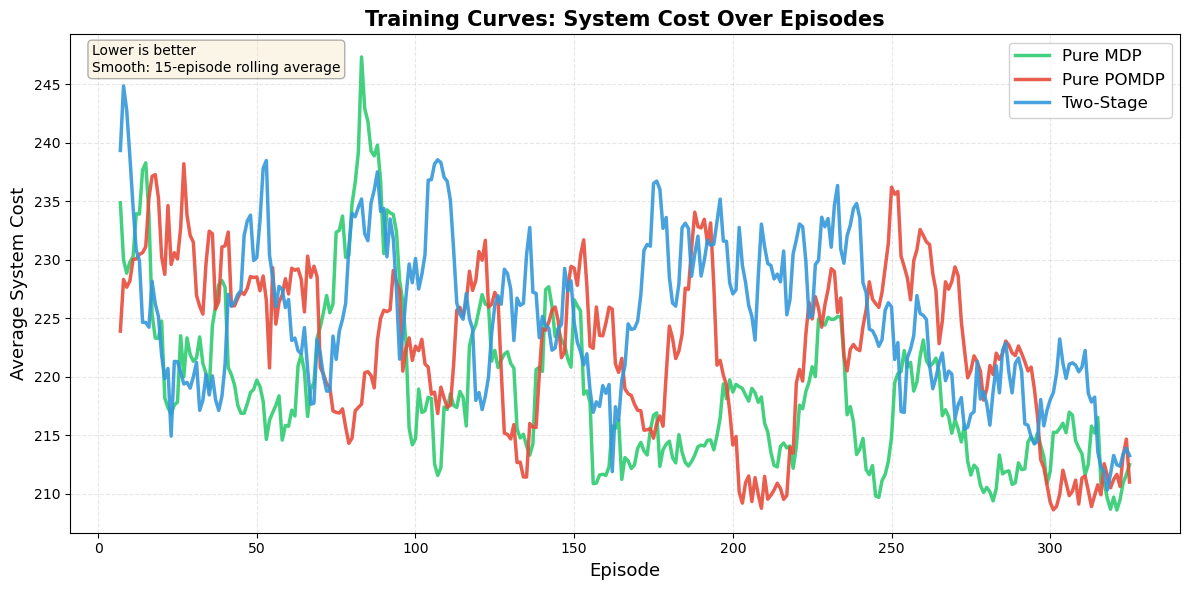

✅ Training curves plotted



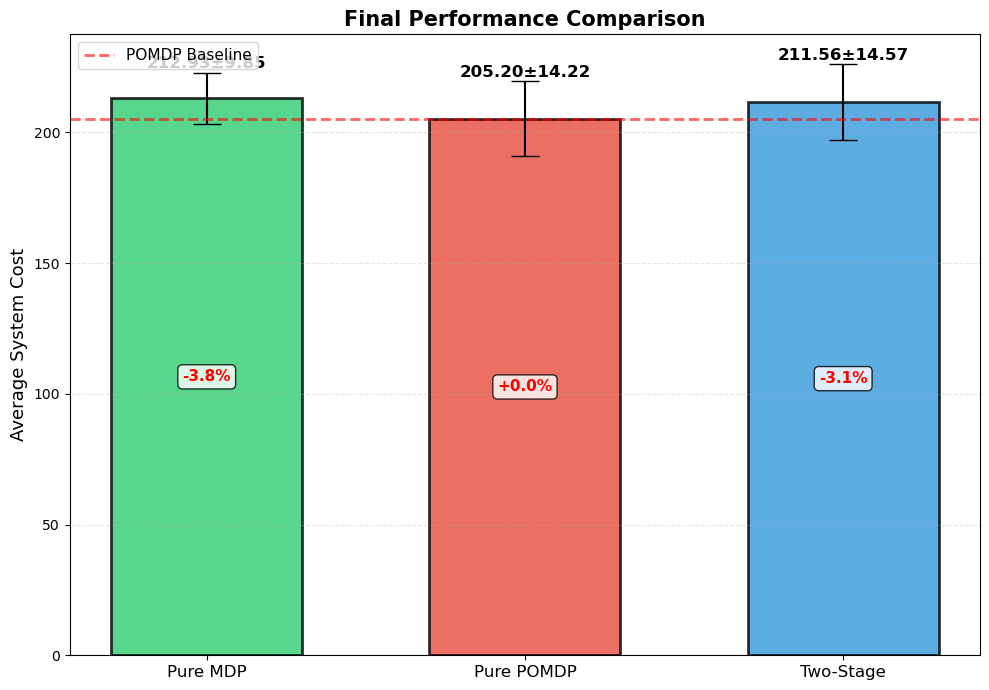

✅ Performance comparison plotted

📊 Performance Summary:
  ⚠️ Pure MDP       : 212.93 (-3.8% vs POMDP)
  ⚠️ Pure POMDP     : 205.20 (+0.0% vs POMDP)
  ⚠️ Two-Stage      : 211.56 (-3.1% vs POMDP)



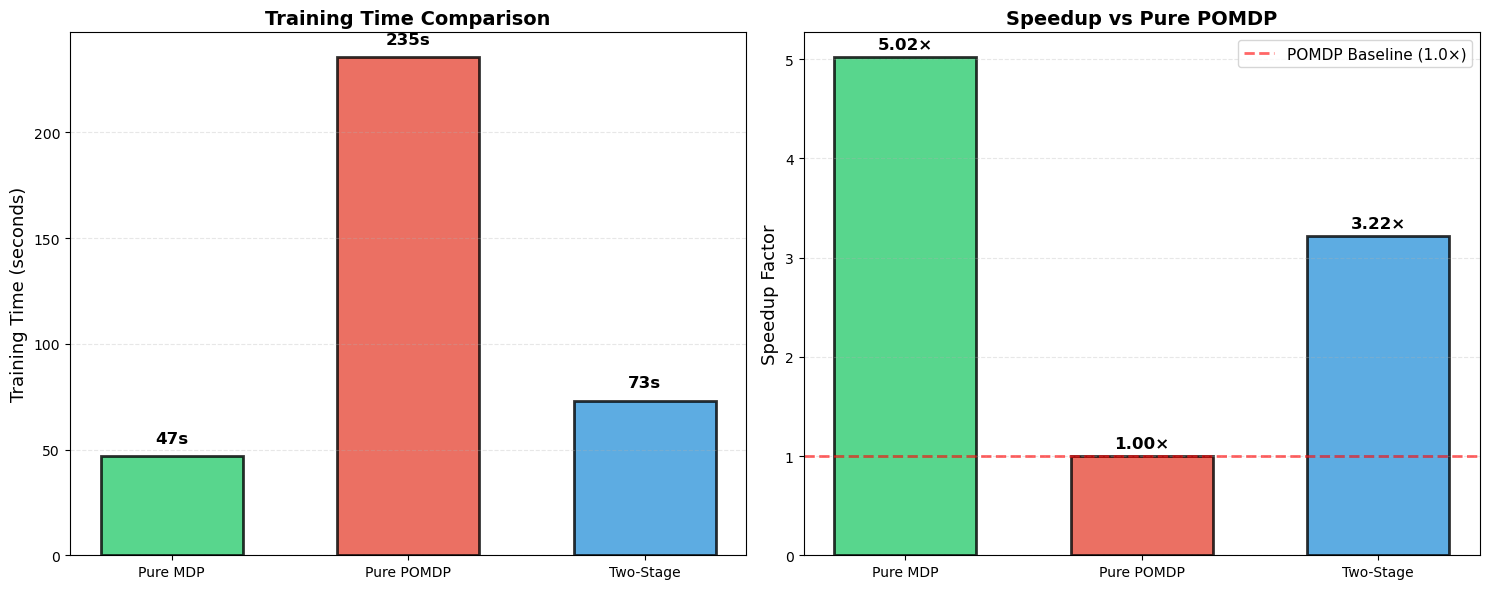

✅ Efficiency comparison plotted

⚡ Efficiency Summary:
  Pure MDP       :     47s (5.02× speedup)
  Pure POMDP     :    235s (1.00× speedup)
  Two-Stage      :     73s (3.22× speedup)



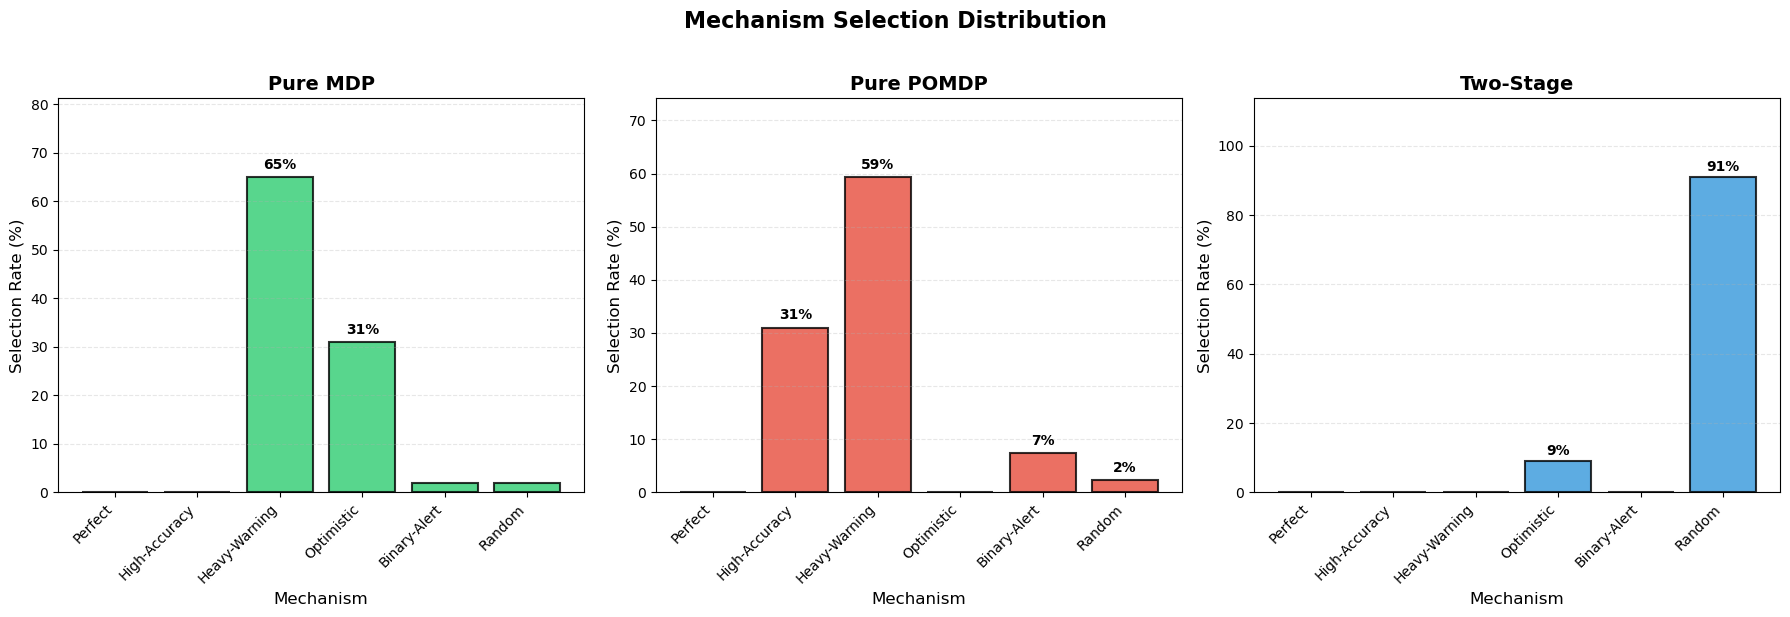

✅ Mechanism selection plotted



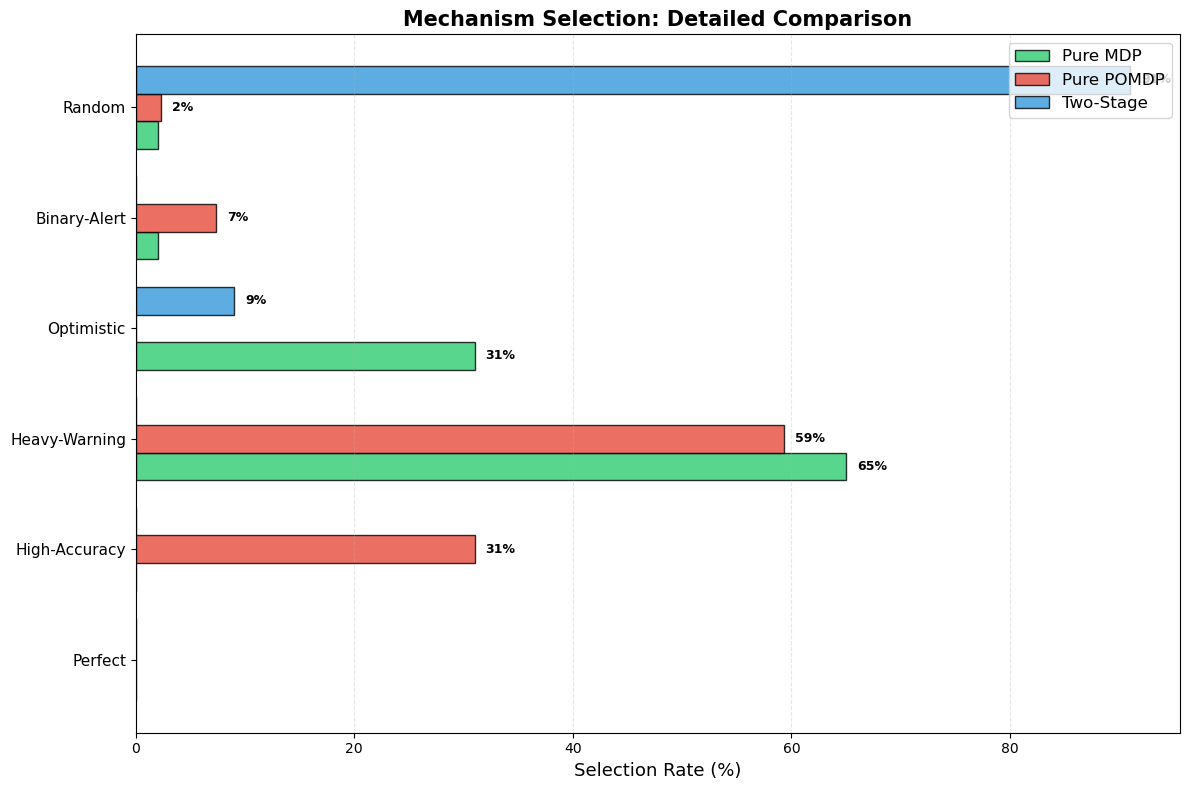

✅ Mechanism analysis plotted



/var/folders/_v/gx7vt7g52nbdb485lxm2c2b80000gn/T/ipykernel_33683/1177311015.py:237: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=methods, patch_artist=True, widths=0.6,


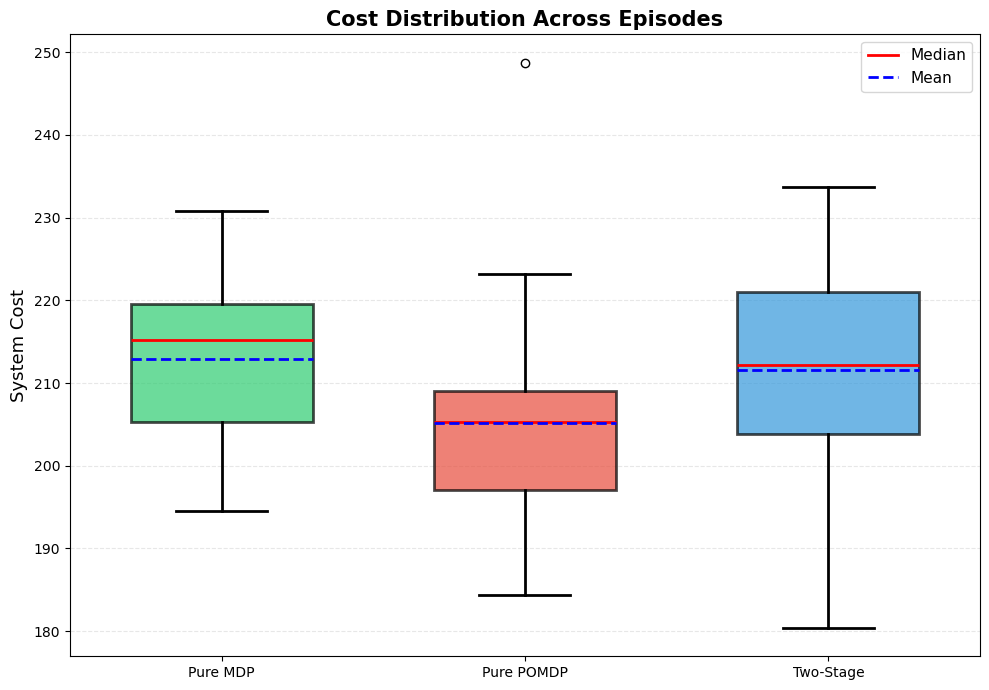

✅ Cost distribution plotted



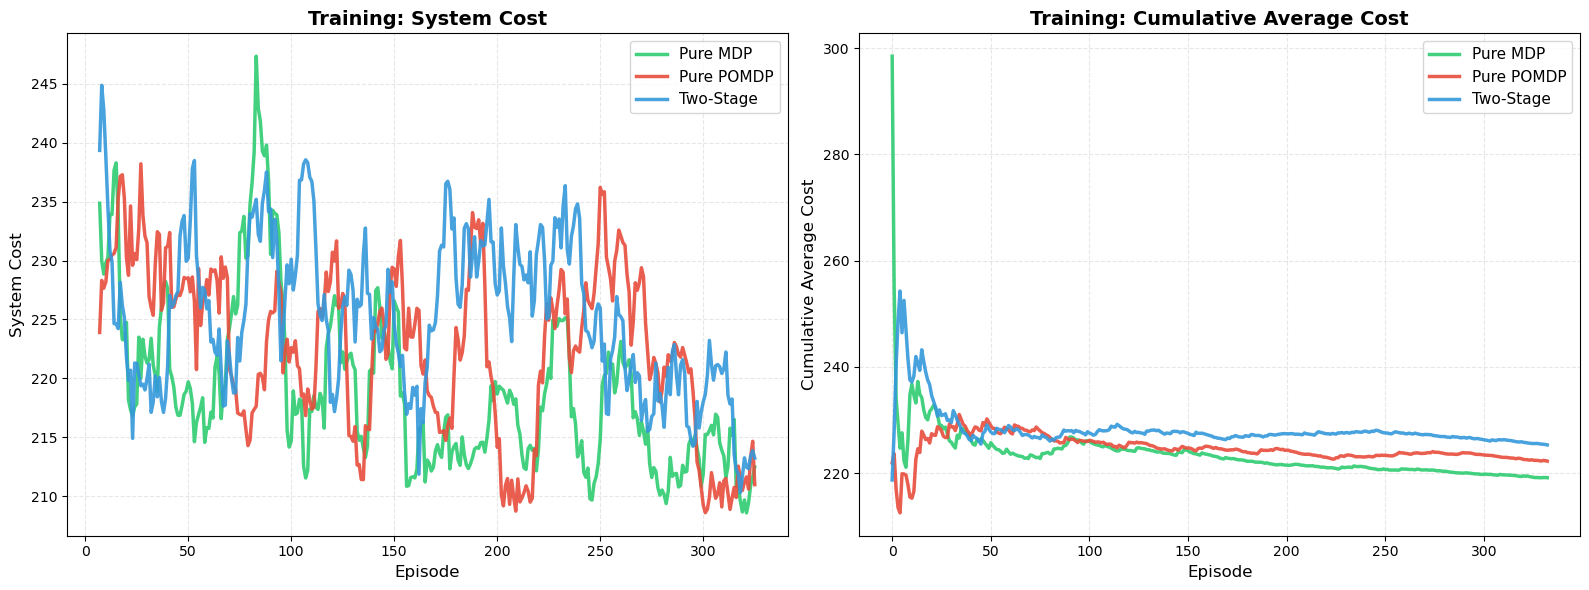

✅ Training comparison plotted



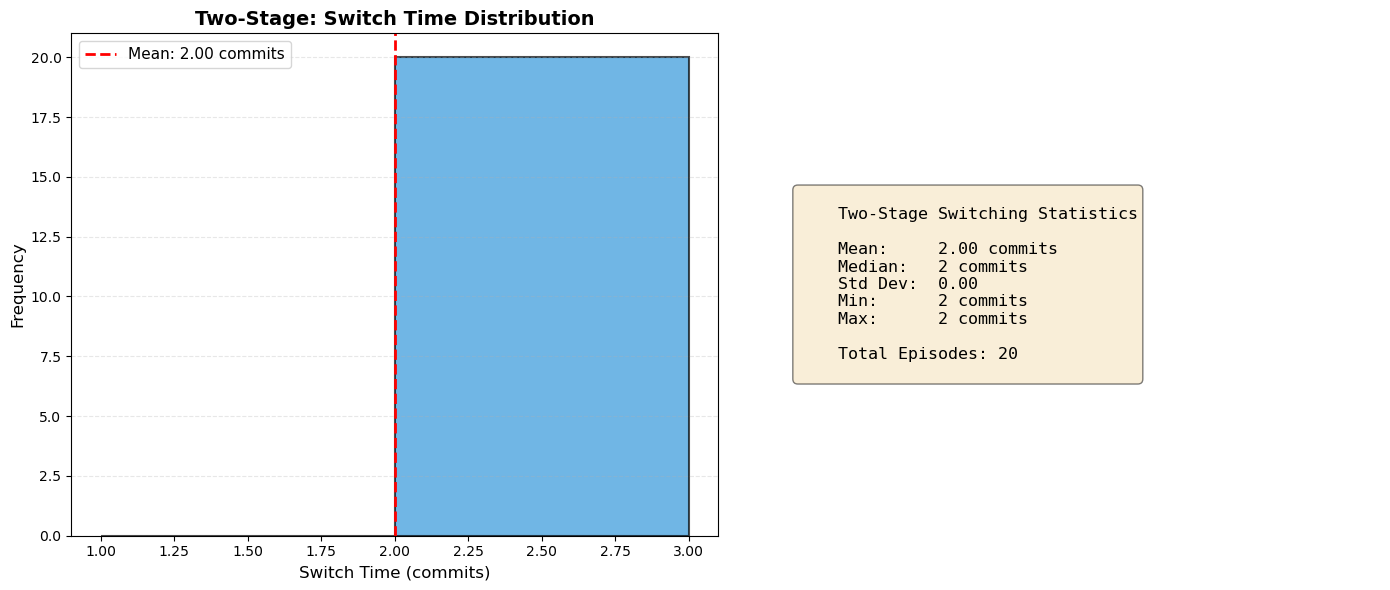

✅ Two-Stage analysis plotted

🔄 Two-Stage Switching:
   Mean: 2.00 commits
   Range: [2, 2]


DETAILED EXPERIMENTAL RESULTS SUMMARY

📊 PERFORMANCE METRICS:

Method          Mean Cost    Std Cost     vs POMDP     Status
--------------------------------------------------------------------------------
Pure MDP            212.93         9.85         -3.8%   ⚠️ Worse
Pure POMDP          205.20        14.22         +0.0%   ≈ Same
Two-Stage           211.56        14.57         -3.1%   ⚠️ Worse

⚡ COMPUTATIONAL EFFICIENCY:

Method          Time (s)     Speedup      Efficiency
--------------------------------------------------------------------------------
Pure MDP                47         5.02×       4.5396
Pure POMDP             235         1.00×       0.8714
Two-Stage               73         3.22×       2.8918

🎯 MECHANISM SELECTION ANALYSIS:

Pure MDP:
  Dominant: Heavy-Warning (65.0%)
  Entropy:  0.446 (0=single, 1=uniform)
  Strategy: 📊 MODERATELY MIXED
  Top 3:
    Heavy-Warning      

In [2]:
"""
=============================================================================
拥堵信号实验 - 完整可视化脚本
=============================================================================

使用方法：
%run sioux_falls_congestion_plotting.py
plot_all()
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle


def plot_training_curves():
    """1. 训练曲线 - Cost随Episode变化"""
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    colors = {'Pure MDP': '#2ecc71', 'Pure POMDP': '#e74c3c', 'Two-Stage': '#3498db'}
    
    for method in ['Pure MDP', 'Pure POMDP', 'Two-Stage']:
        costs = results[method]['train_costs']
        # 滚动平均
        window = min(15, len(costs))
        if len(costs) >= window:
            costs_smooth = pd.Series(costs).rolling(window, center=True).mean()
            ax.plot(costs_smooth, label=method, color=colors[method], linewidth=2.5, alpha=0.9)
    
    ax.set_title('Training Curves: System Cost Over Episodes', fontsize=15, fontweight='bold')
    ax.set_xlabel('Episode', fontsize=13)
    ax.set_ylabel('Average System Cost', fontsize=13)
    ax.legend(fontsize=12, loc='upper right', framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # 添加说明
    textstr = 'Lower is better\nSmooth: 15-episode rolling average'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.3)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.show()
    print("✅ Training curves plotted")


def plot_performance_comparison():
    """2. 性能对比 - 最终Cost柱状图"""
    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    colors = {'Pure MDP': '#2ecc71', 'Pure POMDP': '#e74c3c', 'Two-Stage': '#3498db'}
    
    methods = ['Pure MDP', 'Pure POMDP', 'Two-Stage']
    means = [results[m]['eval']['mean_cost'] for m in methods]
    stds = [results[m]['eval']['std_cost'] for m in methods]
    
    x = np.arange(len(methods))
    bars = ax.bar(x, means, yerr=stds, color=[colors[m] for m in methods],
                   alpha=0.8, capsize=10, width=0.6, edgecolor='black', linewidth=2)
    
    # 添加数值标签
    for i, (bar, mean, std) in enumerate(zip(bars, means, stds)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + std + 0.5,
                f'{mean:.2f}±{std:.2f}', ha='center', va='bottom', 
                fontsize=12, fontweight='bold')
    
    # 添加改进百分比
    baseline_cost = results['Pure POMDP']['eval']['mean_cost']
    for i, method in enumerate(methods):
        cost = results[method]['eval']['mean_cost']
        improvement = (baseline_cost - cost) / baseline_cost * 100
        color = 'green' if improvement > 0 else 'red'
        ax.text(i, means[i]/2, f'{improvement:+.1f}%', ha='center', va='center',
                fontsize=11, fontweight='bold', color=color,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xticks(x)
    ax.set_xticklabels(methods, fontsize=12)
    ax.set_ylabel('Average System Cost', fontsize=13)
    ax.set_title('Final Performance Comparison', fontsize=15, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    # 添加baseline参考线
    ax.axhline(y=baseline_cost, color='red', linestyle='--', alpha=0.6, linewidth=2, label='POMDP Baseline')
    ax.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Performance comparison plotted")
    print(f"\n📊 Performance Summary:")
    for method in methods:
        cost = results[method]['eval']['mean_cost']
        improvement = (baseline_cost - cost) / baseline_cost * 100
        symbol = '✅' if improvement > 0 else '⚠️'
        print(f"  {symbol} {method:<15}: {cost:.2f} ({improvement:+.1f}% vs POMDP)")


def plot_efficiency_comparison():
    """3. 计算效率对比"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    colors = {'Pure MDP': '#2ecc71', 'Pure POMDP': '#e74c3c', 'Two-Stage': '#3498db'}
    
    methods = ['Pure MDP', 'Pure POMDP', 'Two-Stage']
    times = [results[m]['train_time'] for m in methods]
    
    # (1) 训练时间
    ax = axes[0]
    bars = ax.bar(methods, times, color=[colors[m] for m in methods],
                   alpha=0.8, width=0.6, edgecolor='black', linewidth=2)
    
    for bar, t in zip(bars, times):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{t:.0f}s', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    ax.set_ylabel('Training Time (seconds)', fontsize=13)
    ax.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    # (2) 加速比
    ax = axes[1]
    baseline_time = results['Pure POMDP']['train_time']
    speedups = [baseline_time / t for t in times]
    
    bars = ax.bar(methods, speedups, color=[colors[m] for m in methods],
                   alpha=0.8, width=0.6, edgecolor='black', linewidth=2)
    
    for bar, speedup in zip(bars, speedups):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{speedup:.2f}×', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.6, linewidth=2, label='POMDP Baseline (1.0×)')
    ax.set_ylabel('Speedup Factor', fontsize=13)
    ax.set_title('Speedup vs Pure POMDP', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Efficiency comparison plotted")
    print(f"\n⚡ Efficiency Summary:")
    for method, t, speedup in zip(methods, times, speedups):
        print(f"  {method:<15}: {t:>6.0f}s ({speedup:.2f}× speedup)")


def plot_mechanism_selection():
    """4. 机制选择分布 - 三子图"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    colors = {'Pure MDP': '#2ecc71', 'Pure POMDP': '#e74c3c', 'Two-Stage': '#3498db'}
    
    mech_names = [m[0] for m in config.mechanisms]
    methods = ['Pure MDP', 'Pure POMDP', 'Two-Stage']
    
    for idx, method in enumerate(methods):
        ax = axes[idx]
        counts = results[method]['eval']['mechanism_counts']
        total = counts.sum()
        pcts = (counts / total * 100) if total > 0 else counts
        
        bars = ax.bar(range(len(mech_names)), pcts, color=colors[method], alpha=0.8,
                       edgecolor='black', linewidth=1.5)
        
        # 标注百分比
        for bar, pct in zip(bars, pcts):
            if pct > 2:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                        f'{pct:.0f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        ax.set_title(f'{method}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Mechanism', fontsize=12)
        ax.set_ylabel('Selection Rate (%)', fontsize=12)
        ax.set_xticks(range(len(mech_names)))
        ax.set_xticklabels(mech_names, rotation=45, ha='right', fontsize=10)
        ax.grid(True, alpha=0.3, axis='y', linestyle='--')
        ax.set_ylim(0, max(pcts) * 1.25 if max(pcts) > 0 else 100)
    
    plt.suptitle('Mechanism Selection Distribution', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print("✅ Mechanism selection plotted")


def plot_mechanism_analysis():
    """5. 机制选择详细分析 - 水平条形图"""
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    methods = ['Pure MDP', 'Pure POMDP', 'Two-Stage']
    mech_names = [m[0] for m in config.mechanisms]
    colors = {'Pure MDP': '#2ecc71', 'Pure POMDP': '#e74c3c', 'Two-Stage': '#3498db'}
    
    y_offset = 0
    bar_height = 0.25
    
    for method_idx, method in enumerate(methods):
        counts = results[method]['eval']['mechanism_counts']
        total = counts.sum()
        pcts = (counts / total * 100) if total > 0 else counts
        
        y_positions = np.arange(len(mech_names)) * 1.0 + method_idx * bar_height
        
        bars = ax.barh(y_positions, pcts, bar_height, label=method,
                        color=colors[method], alpha=0.8, edgecolor='black', linewidth=1)
        
        # 标注数值
        for bar, pct in zip(bars, pcts):
            if pct > 2:
                width = bar.get_width()
                ax.text(width + 1, bar.get_y() + bar.get_height()/2.,
                        f'{pct:.0f}%', ha='left', va='center', fontsize=9, fontweight='bold')
    
    ax.set_yticks(np.arange(len(mech_names)) * 1.0 + bar_height)
    ax.set_yticklabels(mech_names, fontsize=11)
    ax.set_xlabel('Selection Rate (%)', fontsize=13)
    ax.set_title('Mechanism Selection: Detailed Comparison', fontsize=15, fontweight='bold')
    ax.legend(fontsize=12, loc='upper right')
    ax.grid(True, alpha=0.3, axis='x', linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Mechanism analysis plotted")


def plot_cost_distribution():
    """6. Cost分布 - 箱线图"""
    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    colors = {'Pure MDP': '#2ecc71', 'Pure POMDP': '#e74c3c', 'Two-Stage': '#3498db'}
    
    methods = ['Pure MDP', 'Pure POMDP', 'Two-Stage']
    data = [results[m]['eval']['costs'] for m in methods]
    
    bp = ax.boxplot(data, labels=methods, patch_artist=True, widths=0.6,
                     showmeans=True, meanline=True,
                     boxprops=dict(linewidth=2),
                     whiskerprops=dict(linewidth=2),
                     capprops=dict(linewidth=2),
                     medianprops=dict(color='red', linewidth=2),
                     meanprops=dict(color='blue', linewidth=2, linestyle='--'))
    
    # 填充颜色
    for patch, method in zip(bp['boxes'], methods):
        patch.set_facecolor(colors[method])
        patch.set_alpha(0.7)
    
    ax.set_ylabel('System Cost', fontsize=13)
    ax.set_title('Cost Distribution Across Episodes', fontsize=15, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    # 添加图例说明
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='red', linewidth=2, label='Median'),
        Line2D([0], [0], color='blue', linewidth=2, linestyle='--', label='Mean')
    ]
    ax.legend(handles=legend_elements, fontsize=11, loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Cost distribution plotted")


def plot_training_comparison():
    """7. 训练对比 - 两个子图（Reward + Cost）"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    colors = {'Pure MDP': '#2ecc71', 'Pure POMDP': '#e74c3c', 'Two-Stage': '#3498db'}
    
    methods = ['Pure MDP', 'Pure POMDP', 'Two-Stage']
    
    # (1) Training Costs
    ax = axes[0]
    for method in methods:
        costs = results[method]['train_costs']
        window = min(15, len(costs))
        if len(costs) >= window:
            costs_smooth = pd.Series(costs).rolling(window, center=True).mean()
            ax.plot(costs_smooth, label=method, color=colors[method], linewidth=2.5, alpha=0.9)
    
    ax.set_xlabel('Episode', fontsize=12)
    ax.set_ylabel('System Cost', fontsize=12)
    ax.set_title('Training: System Cost', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # (2) Convergence Analysis
    ax = axes[1]
    for method in methods:
        costs = results[method]['train_costs']
        # 累计平均
        cumulative_avg = np.cumsum(costs) / (np.arange(len(costs)) + 1)
        ax.plot(cumulative_avg, label=method, color=colors[method], linewidth=2.5, alpha=0.9)
    
    ax.set_xlabel('Episode', fontsize=12)
    ax.set_ylabel('Cumulative Average Cost', fontsize=12)
    ax.set_title('Training: Cumulative Average Cost', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Training comparison plotted")


def plot_two_stage_analysis():
    """8. Two-Stage特有分析 - 切换时机"""
    if 'Two-Stage' not in results or not results['Two-Stage']['eval']['switch_commits']:
        print("⚠️ No Two-Stage switching data available")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    switches = results['Two-Stage']['eval']['switch_commits']
    
    # (1) 切换时机直方图
    ax = axes[0]
    ax.hist(switches, bins=range(1, max(switches)+2), color='#3498db', 
            alpha=0.7, edgecolor='black', linewidth=1.5)
    
    mean_switch = np.mean(switches)
    ax.axvline(mean_switch, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_switch:.2f} commits')
    
    ax.set_xlabel('Switch Time (commits)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Two-Stage: Switch Time Distribution', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    # (2) 切换时机统计
    ax = axes[1]
    
    stats_text = f"""
    Two-Stage Switching Statistics
    
    Mean:     {np.mean(switches):.2f} commits
    Median:   {np.median(switches):.0f} commits
    Std Dev:  {np.std(switches):.2f}
    Min:      {np.min(switches)} commits
    Max:      {np.max(switches)} commits
    
    Total Episodes: {len(switches)}
    """
    
    ax.text(0.1, 0.5, stats_text, transform=ax.transAxes, fontsize=12,
            verticalalignment='center', family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Two-Stage analysis plotted")
    print(f"\n🔄 Two-Stage Switching:")
    print(f"   Mean: {np.mean(switches):.2f} commits")
    print(f"   Range: [{np.min(switches)}, {np.max(switches)}]")


def print_detailed_summary():
    """打印详细的文本总结"""
    print("\n" + "="*80)
    print("DETAILED EXPERIMENTAL RESULTS SUMMARY")
    print("="*80)
    
    methods = ['Pure MDP', 'Pure POMDP', 'Two-Stage']
    
    # 性能
    print("\n📊 PERFORMANCE METRICS:")
    print(f"\n{'Method':<15} {'Mean Cost':<12} {'Std Cost':<12} {'vs POMDP':<12} {'Status'}")
    print("-"*80)
    
    baseline_cost = results['Pure POMDP']['eval']['mean_cost']
    for method in methods:
        res = results[method]['eval']
        improvement = (baseline_cost - res['mean_cost']) / baseline_cost * 100
        status = '✅ Better' if improvement > 0 else '⚠️ Worse' if improvement < -1 else '≈ Same'
        print(f"{method:<15} {res['mean_cost']:>10.2f}   {res['std_cost']:>10.2f}   {improvement:>+10.1f}%   {status}")
    
    # 效率
    print("\n⚡ COMPUTATIONAL EFFICIENCY:")
    print(f"\n{'Method':<15} {'Time (s)':<12} {'Speedup':<12} {'Efficiency'}")
    print("-"*80)
    
    baseline_time = results['Pure POMDP']['train_time']
    for method in methods:
        t = results[method]['train_time']
        speedup = baseline_time / t
        cost = results[method]['eval']['mean_cost']
        efficiency = cost / t  # cost per second (lower is better)
        print(f"{method:<15} {t:>10.0f}   {speedup:>10.2f}×   {efficiency:>10.4f}")
    
    # 机制选择
    print("\n🎯 MECHANISM SELECTION ANALYSIS:")
    for method in methods:
        print(f"\n{method}:")
        counts = results[method]['eval']['mechanism_counts']
        total = counts.sum()
        
        # 找主导机制
        dominant_idx = np.argmax(counts)
        dominant_pct = (counts[dominant_idx] / total * 100) if total > 0 else 0
        dominant_name = config.mechanisms[dominant_idx][0]
        
        # 计算熵
        probs = counts / total if total > 0 else counts
        probs = probs[probs > 0]
        entropy = -np.sum(probs * np.log(probs)) if len(probs) > 0 else 0
        max_entropy = np.log(len(config.mechanisms))
        normalized_entropy = entropy / max_entropy if max_entropy > 0 else 0
        
        print(f"  Dominant: {dominant_name} ({dominant_pct:.1f}%)")
        print(f"  Entropy:  {normalized_entropy:.3f} (0=single, 1=uniform)")
        
        # 策略类型
        if dominant_pct > 85:
            print(f"  Strategy: ⭐ SINGLE DOMINANT")
        elif dominant_pct > 65:
            print(f"  Strategy: 🎯 PRIMARY + ALTERNATIVES")
        elif normalized_entropy > 0.7:
            print(f"  Strategy: 🌈 HIGHLY MIXED")
        else:
            print(f"  Strategy: 📊 MODERATELY MIXED")
        
        # Top 3机制
        top3_indices = np.argsort(counts)[-3:][::-1]
        print(f"  Top 3:")
        for idx in top3_indices:
            if counts[idx] > 0:
                pct = (counts[idx] / total * 100) if total > 0 else 0
                name = config.mechanisms[idx][0]
                print(f"    {name:<20s}: {pct:>5.1f}%")
    
    # Two-Stage特殊信息
    if 'Two-Stage' in results and results['Two-Stage']['eval']['switch_commits']:
        switches = results['Two-Stage']['eval']['switch_commits']
        print(f"\n🔄 TWO-STAGE SWITCHING:")
        print(f"  Mean Switch:  {np.mean(switches):.2f} commits")
        print(f"  Median:       {np.median(switches):.0f} commits")
        print(f"  Range:        [{np.min(switches)}, {np.max(switches)}]")
        print(f"  Std Dev:      {np.std(switches):.2f}")
    
    print("\n" + "="*80)


def plot_all():
    """生成所有图表"""
    print("\n" + "="*80)
    print("GENERATING ALL PLOTS")
    print("="*80 + "\n")
    
    plot_training_curves()
    print()
    
    plot_performance_comparison()
    print()
    
    plot_efficiency_comparison()
    print()
    
    plot_mechanism_selection()
    print()
    
    plot_mechanism_analysis()
    print()
    
    plot_cost_distribution()
    print()
    
    plot_training_comparison()
    print()
    
    plot_two_stage_analysis()
    print()
    
    print_detailed_summary()
    
    print("\n" + "="*80)
    print("✅ ALL PLOTS GENERATED")
    print("="*80)


# 加载提示
print("\n" + "="*80)
print("📊 Plotting Functions Ready for Congestion Signals Experiment")
print("="*80)
print("\nAvailable functions:")
print("  plot_all()                    # 生成所有图表（推荐）")
print("  plot_training_curves()        # 训练曲线")
print("  plot_performance_comparison() # 性能对比柱状图")
print("  plot_efficiency_comparison()  # 计算效率对比")
print("  plot_mechanism_selection()    # 机制选择分布（3子图）")
print("  plot_mechanism_analysis()     # 机制选择详细分析")
print("  plot_cost_distribution()      # Cost分布箱线图")
print("  plot_training_comparison()    # 训练对比（2子图）")
print("  plot_two_stage_analysis()     # Two-Stage切换分析")
print("  print_detailed_summary()      # 打印详细文本总结")
print("\n💡 Quick start:")
print("   plot_all()  # 一次性生成所有图表和总结")
print("="*80 + "\n")
plot_all()